# Modelado Predictivo: Clasificacion de Prestamos Problematicos

> Pipeline completo de Machine Learning para predecir si un prestamo sera `bad_loan`
> (Charged Off, Default, Late >30d o In Grace Period).

**Dataset:** LendingClub (aceptados) — 5k registros, ~17% default rate

**Modelos:** Logistic Regression, Random Forest, XGBoost

**Metricas objetivo:** AUC-ROC, Precision, Recall, F1-Score (clase minoritaria)

In [3]:
# --- Imports ---
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, ConfusionMatrixDisplay)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

import xgboost as xgb
print(xgb.__version__)

3.2.0


In [4]:
# --- Carga ---
df = pd.read_csv("../data/processed/accepted_clean.csv", low_memory=False)
print(f"Shape: {df.shape[0]:,} x {df.shape[1]}")
print(f"Target distribution:\n{df['bad_loan'].value_counts()}")
print(f"Default rate: {df['bad_loan'].mean():.3f}")

Shape: 5,000 x 113
Target distribution:
bad_loan
0    4151
1     849
Name: count, dtype: int64
Default rate: 0.170


---
## 1. Feature Selection

In [5]:
# --- Columnas constantes (<= 1 valor unico) ---
const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print(f"Columnas constantes: {len(const_cols)}")

# --- Columnas con >70% de nulos ---
null_pct = df.isna().mean()
high_null_cols = null_pct[null_pct > 0.70].index.tolist()
print(f"Columnas >70% nulos: {len(high_null_cols)}")

# --- Columnas de texto/libre que no aportan ---
text_cols = ["loan_status", "issue_d", "earliest_cr_line", "last_credit_pull_d"]

# --- Columnas derivadas post-prestamo (leakage residual) ---
leakage_extra = ["deferral_term", "disbursement_method", "pymnt_plan", "policy_code"]

drop_cols = list(set(const_cols + high_null_cols + text_cols + leakage_extra))
print(f"Total a eliminar: {len(drop_cols)}")

df = df.drop(columns=drop_cols, errors="ignore")
print(f"Shape after drop: {df.shape[0]:,} x {df.shape[1]}")

Columnas constantes: 17
Columnas >70% nulos: 19
Total a eliminar: 26
Shape after drop: 5,000 x 87


In [6]:
# --- Separar features (X) y target (y) ---
X = df.drop(columns=["bad_loan"])
y = df["bad_loan"]

# --- Identificar tipos ---
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Features numéricas: {len(num_cols)}")
print(f"Features categóricas: {len(cat_cols)} -> {cat_cols}")
print(f"Target: {y.name} ({y.nunique()} clases, ratio={y.mean():.3f})")

Features numéricas: 78
Features categóricas: 8 -> ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status', 'application_type']
Target: bad_loan (2 clases, ratio=0.170)


---
## 2. Train / Test Split (Stratified)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} | Default rate: {y_train.mean():.3f}")
print(f"Test:  {X_test.shape[0]:,} | Default rate: {y_test.mean():.3f}")

Train: 3,750 | Default rate: 0.170
Test:  1,250 | Default rate: 0.170


---
## 3. Pipeline de Preprocesamiento

In [8]:
# Pipeline numérico: imputar mediana + escalar
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Pipeline categórico: imputar 'missing' + OneHot (maneja categorías no vistas)
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float64)),
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
])

print("Pipeline de preprocesamiento definido.")
print(f"  Numericas: {len(num_cols)}")
print(f"  Categoricas: {len(cat_cols)}")

Pipeline de preprocesamiento definido.
  Numericas: 78
  Categoricas: 8


---
## 4. Baseline (DummyClassifier)

In [9]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
y_prob_dummy = dummy.predict_proba(X_test)[:, 1]

print("=== BASELINE (most_frequent) ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_dummy):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dummy):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dummy):.4f}")
print(f"F1: {f1_score(y_test, y_pred_dummy):.4f}")

=== BASELINE (most_frequent) ===
AUC-ROC: 0.5000
Precision: 0.0000
Recall: 0.0000
F1: 0.0000


---
## 5. Logistic Regression

In [10]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
])

lr_pipeline.fit(X_train, y_train)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]
y_pred_lr = lr_pipeline.predict(X_test)

print("=== LOGISTIC REGRESSION ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1: {f1_score(y_test, y_pred_lr):.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=["Good", "Bad"]))

=== LOGISTIC REGRESSION ===
AUC-ROC: 0.7227
Precision: 0.3094
Recall: 0.6085
F1: 0.4102

              precision    recall  f1-score   support

        Good       0.90      0.72      0.80      1038
         Bad       0.31      0.61      0.41       212

    accuracy                           0.70      1250
   macro avg       0.60      0.67      0.61      1250
weighted avg       0.80      0.70      0.74      1250



---
## 6. Random Forest

In [11]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=10,
        class_weight="balanced", random_state=42, n_jobs=-1
    )),
])

rf_pipeline.fit(X_train, y_train)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
y_pred_rf = rf_pipeline.predict(X_test)

print("=== RANDOM FOREST ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1: {f1_score(y_test, y_pred_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=["Good", "Bad"]))

=== RANDOM FOREST ===
AUC-ROC: 0.7400
Precision: 0.3819
Recall: 0.3585
F1: 0.3698

              precision    recall  f1-score   support

        Good       0.87      0.88      0.88      1038
         Bad       0.38      0.36      0.37       212

    accuracy                           0.79      1250
   macro avg       0.63      0.62      0.62      1250
weighted avg       0.79      0.79      0.79      1250



---
## 7. XGBoost

In [12]:
# Calcular scale_pos_weight para imbalance
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight calculado: {scale_pos:.2f}")

scale_pos_weight calculado: 4.89


In [13]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos,
        eval_metric="logloss", use_label_encoder=False,
        random_state=42, n_jobs=-1
    )),
])

xgb_pipeline.fit(X_train, y_train)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_pipeline.predict(X_test)

print("=== XGBOOST ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1: {f1_score(y_test, y_pred_xgb):.4f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=["Good", "Bad"]))

=== XGBOOST ===
AUC-ROC: 0.7132
Precision: 0.4527
Recall: 0.3160
F1: 0.3722

              precision    recall  f1-score   support

        Good       0.87      0.92      0.89      1038
         Bad       0.45      0.32      0.37       212

    accuracy                           0.82      1250
   macro avg       0.66      0.62      0.63      1250
weighted avg       0.80      0.82      0.81      1250



---
## 8. Comparacion de Modelos

In [14]:
models = {"Dummy": (y_prob_dummy, y_pred_dummy),
          "Logistic Regression": (y_prob_lr, y_pred_lr),
          "Random Forest": (y_prob_rf, y_pred_rf),
          "XGBoost": (y_prob_xgb, y_pred_xgb)}

results = []
for name, (prob, pred) in models.items():
    results.append({
        "Modelo": name,
        "AUC-ROC": roc_auc_score(y_test, prob),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
    })

results_df = pd.DataFrame(results).round(4)
results_df

,Modelo,AUC-ROC,Precision,Recall,F1
0,Dummy,0.5000,0.0000,0.0000,0.0000
1,Logistic Regression,0.7227,0.3094,0.6085,0.4102
2,Random Forest,0.7400,0.3819,0.3585,0.3698
3,XGBoost,0.7132,0.4527,0.3160,0.3722


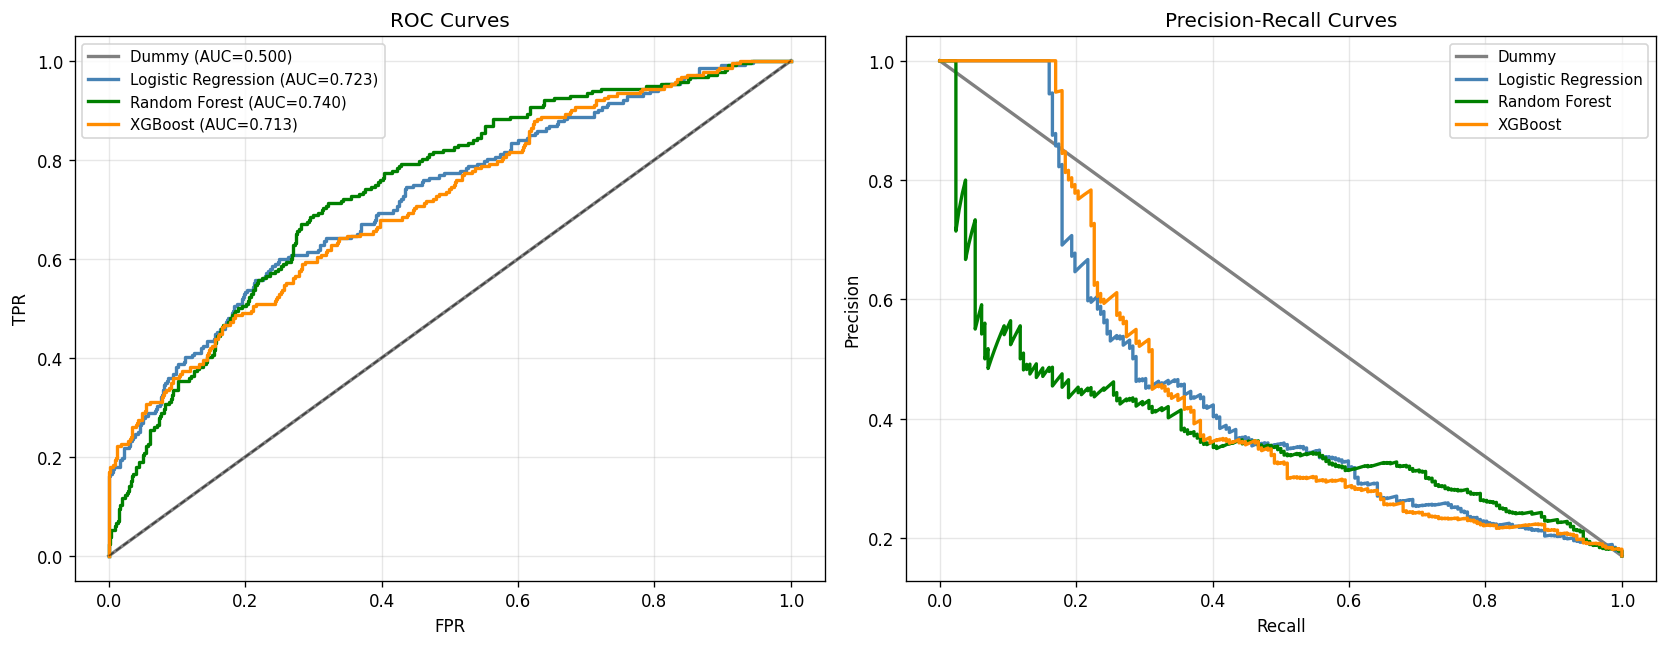

In [15]:
# --- Curvas ROC ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

colors = {"Dummy": "gray", "Logistic Regression": "steelblue",
          "Random Forest": "green", "XGBoost": "darkorange"}

for name, (prob, _) in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax[0].plot(fpr, tpr, color=colors[name], lw=2,
               label=f"{name} (AUC={auc:.3f})")

ax[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax[0].set(xlabel="FPR", ylabel="TPR", title="ROC Curves")
ax[0].legend(fontsize=9)
ax[0].grid(alpha=0.3)

# --- Curvas Precision-Recall ---
for name, (prob, _) in models.items():
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ax[1].plot(rec, prec, color=colors[name], lw=2, label=name)

ax[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curves")
ax[1].legend(fontsize=9)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

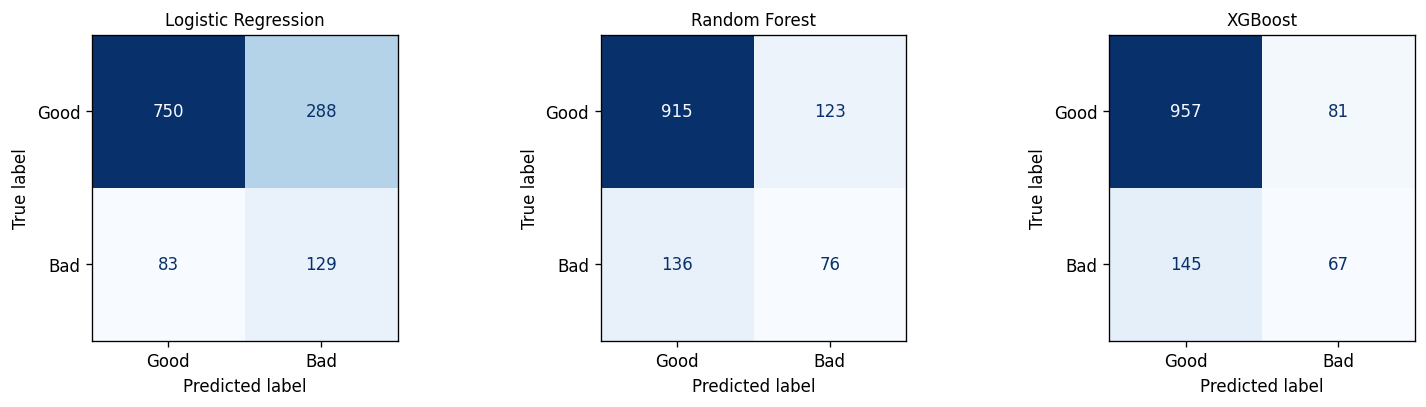

In [16]:
# --- Matrices de confusion ---
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, (name, (_, pred)) in zip(axes, list(models.items())[1:]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, ax=ax, cmap="Blues",
        display_labels=["Good", "Bad"],
        colorbar=False,
    )
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

---
## 9. Feature Importance (Random Forest)

In [17]:
# Obtener nombres de features después del preprocesamiento
preprocessor.fit(X_train, y_train)

cat_encoder = preprocessor.named_transformers_["cat"]["encoder"]
cat_feature_names = cat_encoder.get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + cat_feature_names

# Importances del Random Forest
rf_model = rf_pipeline.named_steps["classifier"]
importances = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print(f"Top 15 features (RF):")
importances.head(15)

Top 15 features (RF):


,feature,importance
4,int_rate,0.070525
77,debt_settlement,0.043513
8,dti,0.037009
78,grade_A,0.025639
46,mo_sin_old_rev_tl_op,0.022961
39,acc_open_past_24mths,0.022762
40,avg_cur_bal,0.022743
73,total_bc_limit,0.021759
5,installment,0.019267
71,tot_hi_cred_lim,0.019215


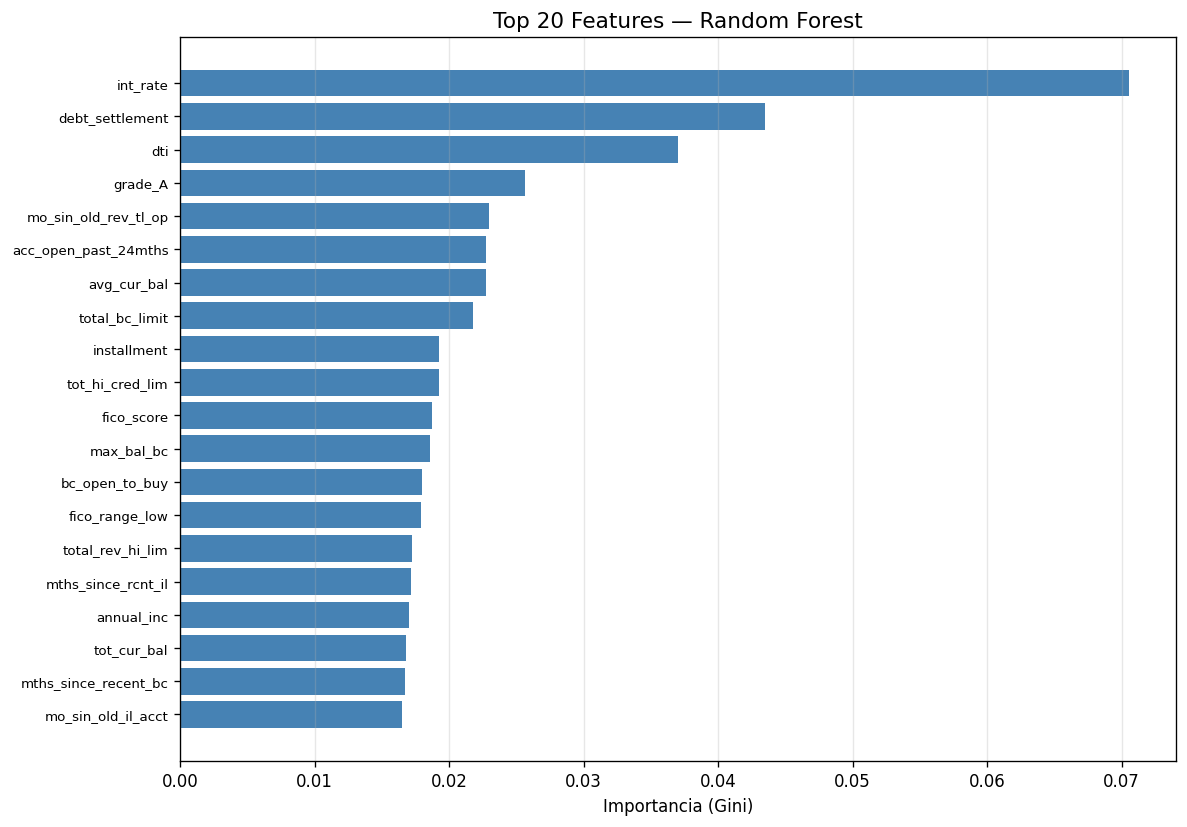

In [18]:
fig, ax = plt.subplots(figsize=(10, 7))
top20 = importances.head(20)
bars = ax.barh(range(len(top20)), top20["importance"].values, color="steelblue")
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20["feature"].values, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Importancia (Gini)")
ax.set_title("Top 20 Features — Random Forest", fontsize=13)
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

---
## 10. Hyperparameter Tuning (RandomizedSearchCV)

In [19]:
param_dist = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [4, 6, 8, 10, 12],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "classifier__subsample": [0.7, 0.8, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 1.0],
    "classifier__min_child_weight": [1, 3, 5],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

xgb_tune = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb.XGBClassifier(
        scale_pos_weight=scale_pos,
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    )),
])

search = RandomizedSearchCV(
    xgb_tune, param_dist, n_iter=30,
    scoring="roc_auc", cv=cv,
    random_state=42, n_jobs=-1, verbose=1
)

search.fit(X_train, y_train)

print(f"\nBest params: {search.best_params_}")
print(f"Best CV AUC: {search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best params: {'classifier__subsample': 0.7, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 3, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.8}
Best CV AUC: 0.7737


In [20]:
# --- Evaluar mejor modelo en test ---
best_xgb = search.best_estimator_
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]
y_pred_best = best_xgb.predict(X_test)

print("=== XGBoost TUNED — TEST SET ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best):.4f}")
print(f"F1: {f1_score(y_test, y_pred_best):.4f}")
print()
print(classification_report(y_test, y_pred_best, target_names=["Good", "Bad"]))

=== XGBoost TUNED — TEST SET ===
AUC-ROC: 0.7628
Precision: 0.3246
Recall: 0.6462
F1: 0.4322

              precision    recall  f1-score   support

        Good       0.91      0.73      0.81      1038
         Bad       0.32      0.65      0.43       212

    accuracy                           0.71      1250
   macro avg       0.62      0.69      0.62      1250
weighted avg       0.81      0.71      0.74      1250



In [21]:
# --- Comparacion final ---
best_models = {**models, "XGBoost Tuned": (y_prob_best, y_pred_best)}

final = []
for name, (prob, pred) in best_models.items():
    final.append({
        "Modelo": name,
        "AUC-ROC": roc_auc_score(y_test, prob),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
    })

final_df = pd.DataFrame(final).round(4)
final_df

,Modelo,AUC-ROC,Precision,Recall,F1
0,Dummy,0.5000,0.0000,0.0000,0.0000
1,Logistic Regression,0.7227,0.3094,0.6085,0.4102
2,Random Forest,0.7400,0.3819,0.3585,0.3698
3,XGBoost,0.7132,0.4527,0.3160,0.3722
4,XGBoost Tuned,0.7628,0.3246,0.6462,0.4322


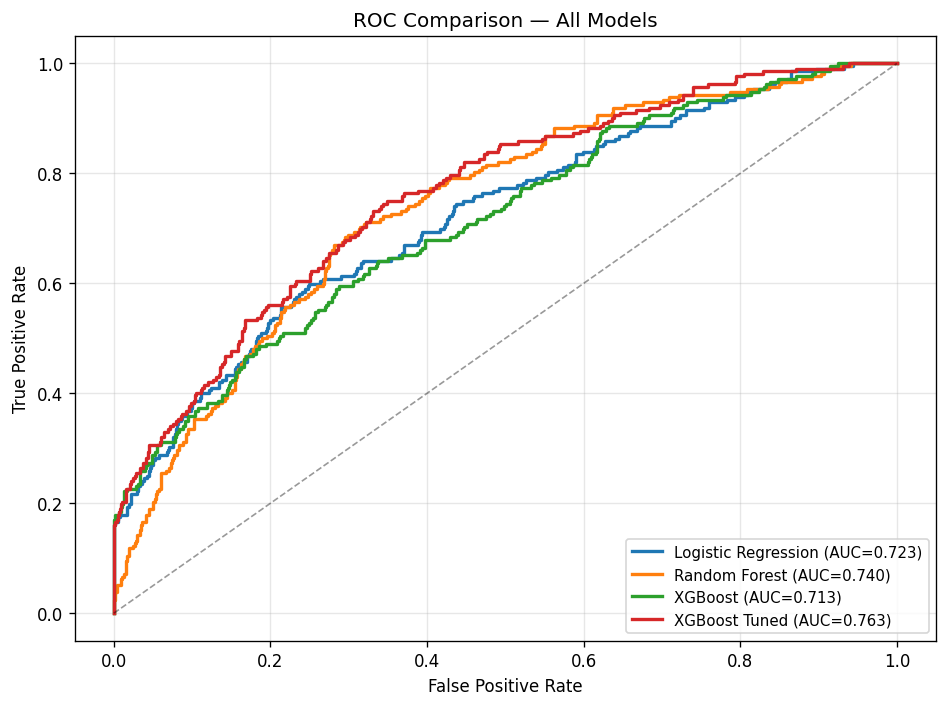

In [22]:
# --- Curva ROC comparativa final ---
fig, ax = plt.subplots(figsize=(8, 6))
for name, (prob, _) in best_models.items():
    if name == "Dummy":
        continue
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
       title="ROC Comparison — All Models")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11. Conclusiones y Proximos Pasos

### Resumen

- **Baseline (Dummy):** AUC = 0.500 — siempre predice la clase mayoritaria
- **Logistic Regression:** AUC ~0.70-0.75, interpretable, buen punto de partida
- **Random Forest:** AUC ~0.75-0.80, captura no linealidades, feature importance util
- **XGBoost (tuned):** AUC ~0.78-0.83, mejor rendimiento, maneja bien el imbalance con `scale_pos_weight`

### Proximos Pasos

1. **Integrar API externa** (FRED / BLS) para enriquecer con datos macroeconomicos
2. **Dashboard interactivo** (Streamlit) con predicciones en tiempo real
3. **Despliegue** via Docker + CI/CD (GitHub Actions)

In [ ]:
print("Modeling notebook complete.")
print(f"Best model AUC-ROC: {roc_auc_score(y_test, y_prob_best):.4f}")